# An Overview of Hurricane Helene's Genesis and Intensification (2024)

```{image} ../thumbnails/thumbnail.png
:alt: Project Pythia logo
:width: 200px
```

---

## Overview

This notebook explores the early development and rapid intensification of Hurricane Helene (2024).  
Using ERA5 reanalysis data and NHC best-track observations, we analyze the environmental factors that supported Helene’s strengthening as it moved across the Atlantic.

1. Retrieve and visualize Helene’s best-track from IBTrACS and plot the Sea Surface Temperatures (SSTs)
2. Plot 850 to 200hPa deep layer steering flow and 200hPa winds/jetstream from ERA5  
3. Examine the vertical structure and steering flow influencing storm motion  
4. Identify conditions favorable for rapid intensification and the 10m windfield size  
5. Summarize how large-scale dynamics guided Helene’s early evolution and track forcast confidence

By the end, the following will have been discussed: 
- the shear size of Helene, as it was determined to be around the 90th percentile in size for tropical cyclones that come from the Central American Gyre
- its track accuracy that was well forecasted a week in advance
- its rapid intensification and storm surge impacts along the West Coast of Florida and Apalachee Bay (explored more in the second notebook)

---

## Prerequisites 

## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Intro to Cartopy](https://foundations.projectpythia.org/core/cartopy/cartopy) | Necessary | Used to visualize Helene’s track and environmental fields |
| [Working with xarray and ERA5 data](https://foundations.projectpythia.org/core/xarray/xarray) | Necessary | Required for reading and manipulating reanalysis datasets |
| [NetCDF data structure](https://foundations.projectpythia.org/core/data-formats/netcdf-cf) | Helpful | Understanding coordinate and variable metadata |
| Tropical cyclone dynamics | Helpful | Background on factors driving cyclone formation and intensification |

- **Time to learn:** ~15 minutes  
- **System requirements:** ERA5 data access (via [Copernicus CDS API](https://cds.climate.copernicus.eu/api-how-to)), ~2 GB disk space for three-day subset  


---

### Imports

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import datetime as dt
import cdsapi
import s3fs


#plotting features 
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches


import datetime as dt
from concurrent.futures import ThreadPoolExecutor

### To begin, let's focus on where Helene formed, the Central American Gyre. The CAG is a region of enhanced convergence in the Carribbean and Central America where tropical cyclones can originate. Notably, two of the strongest hurricanes in the 2024 hurricane season, Helene and Milton (Category 5 with Rapid Intensification twice), originated from the Gyre. Some argue that Gulf Hurricanes are more perilous than Atlantic Hurricanes, purely due to the reduced response and preparation time. 

### I am slicing the latitude, longitude, and time period I want, and ChatGPT helped me set up this useful dictionary format to do so for a specific lat lon region. The time range is a simple slice of the time strings 

## First Section: IBTrACS Visualization

In [2]:
region = dict(lat=slice(5, 35), lon=slice(-60, -10))
time_range = slice("2024-09-20", "2024-09-26")

### Read the csv file directly through its link and prevent an unnecessary download. Let's check what variables are in this csv file by printing the columns.

In [3]:
ib = pd.read_csv("https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r01/access/csv/ibtracs.ALL.list.v04r01.csv", skiprows=[1])

/tmp/ipykernel_1218183/1426075803.py:1: DtypeWarning: Columns (19,20,23,172,173) have mixed types. Specify dtype option on import or set low_memory=False.
  ib = pd.read_csv("https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r01/access/csv/ibtracs.ALL.list.v04r01.csv", skiprows=[1])


In [4]:
print(ib.columns[:41])

Index(['SID', 'SEASON', 'NUMBER', 'BASIN', 'SUBBASIN', 'NAME', 'ISO_TIME',
       'NATURE', 'LAT', 'LON', 'WMO_WIND', 'WMO_PRES', 'WMO_AGENCY',
       'TRACK_TYPE', 'DIST2LAND', 'LANDFALL', 'IFLAG', 'USA_AGENCY',
       'USA_ATCF_ID', 'USA_LAT', 'USA_LON', 'USA_RECORD', 'USA_STATUS',
       'USA_WIND', 'USA_PRES', 'USA_SSHS', 'USA_R34_NE', 'USA_R34_SE',
       'USA_R34_SW', 'USA_R34_NW', 'USA_R50_NE', 'USA_R50_SE', 'USA_R50_SW',
       'USA_R50_NW', 'USA_R64_NE', 'USA_R64_SE', 'USA_R64_SW', 'USA_R64_NW',
       'USA_POCI', 'USA_ROCI', 'USA_RMW'],
      dtype='object')


### Time to subset or filter through the large IBTrACS dataset to find all the columns where the name corresponds to Helene and the year is 2024. Then, the columns of interested selected from the above print are listed for the table, and the time column is converted to a proper datetime format via the datetime python package.

In [5]:
helene = ib[(ib['NAME'] == 'HELENE') & (ib['SEASON'] == 2024)]
helene = helene[['ISO_TIME','LAT','LON','USA_WIND', 'USA_PRES', 'USA_STATUS']]
helene['ISO_TIME'] = pd.to_datetime(helene['ISO_TIME'])
helene.head()

,ISO_TIME,LAT,LON,USA_WIND,USA_PRES,USA_STATUS
715230,2024-09-23 12:00:00,17.2,-81.7,30,1004,DB
715231,2024-09-23 15:00:00,17.5,-81.8,33,1004,DB
715232,2024-09-23 18:00:00,17.8,-81.9,35,1004,DB
715233,2024-09-23 21:00:00,18.0,-82.0,35,1003,DB
715234,2024-09-24 00:00:00,18.2,-82.2,35,1002,DB


### To ensure the data is actual numbers or numerical instead of still in string format, the .to_numeric method is used to convert data to integers or floats, and if a piece of data cannot be converted properly, it will become NaN and then, to ensure no missing data errors, the errors='coerce' argument is used to overlook missing data errors. This is done to the winds, latitude, longitude, and pressure 

In [6]:
helene['LAT'] = pd.to_numeric(helene['LAT'], errors='coerce')
helene['LON'] = pd.to_numeric(helene['LON'], errors='coerce')
helene['USA_PRES'] = pd.to_numeric(helene['USA_PRES'], errors='coerce')
helene['USA_WIND'] = pd.to_numeric(helene['USA_WIND'], errors='coerce')

### Time to plot the labeled pressure and windspeeds of Helene alongside its track. comments detailing the process are specified throughout.

Text(0.5, 1.0, 'Hurricane Helene (2024) Track and Intensity from IBTrACS')

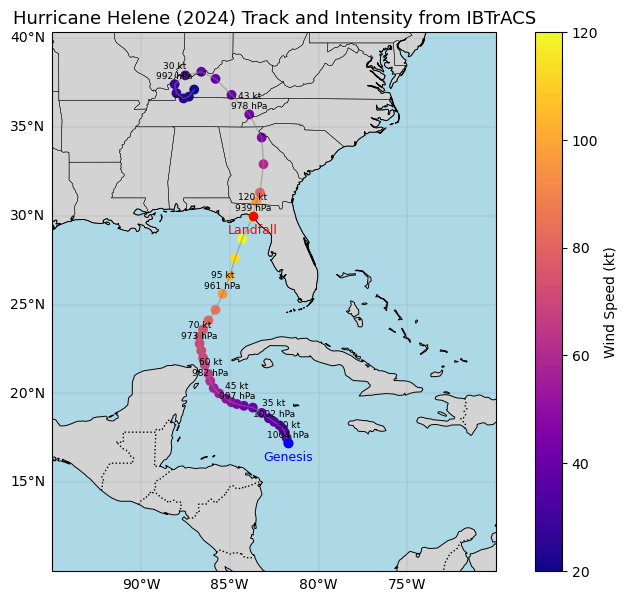

In [7]:
#begin plotting by specifying the figure size, selecting the PlateCarree projection style, and setting the axis extent to the area that best captures Helene's track
fig = plt.figure(figsize=(10,7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-95, -70, 10, 40])  # adjust for Atlantic view

#map features - aesthetics 
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linewidth=0.3)

#scatter Helene's corresponding wind data organized by coordinates with the plasma colorbar option
sc = ax.scatter(helene['LON'], helene['LAT'], c=helene['USA_WIND'], cmap='plasma', s=50, edgecolors='none', linewidth=0.5, transform=ccrs.PlateCarree())
plt.colorbar(sc, ax=ax, label='Wind Speed (kt)')

#to reduce the density of labeled points, label only every 5 points of Helene's track with wind and pressure data using the iloc method in a loop (ChatGPT helped me with this loop)
for i, row in helene.iloc[::5].iterrows():
    label = f"{int(row['USA_WIND'])} kt\n{int(row['USA_PRES'])} hPa"
    ax.text(row['LON'], row['LAT'] + 0.3, label, fontsize=6.5, color='black', ha='center', transform=ccrs.PlateCarree())

#plot Helene's lat and lon points 
ax.plot(helene['LON'], helene['LAT'], color='gray', linewidth=1, transform=ccrs.PlateCarree(), alpha=0.5)

#label the genesis point 
ax.text(helene['LON'].iloc[0], helene['LAT'].iloc[0]-1, 'Genesis', fontsize=9, ha='center', color='blue', transform=ccrs.PlateCarree())
ax.plot(helene['LON'].iloc[0], helene['LAT'].iloc[0], 'bo', transform=ccrs.PlateCarree())

#label Helene's landfall point
ax.text(helene['LON'].iloc[-15], helene['LAT'].iloc[-15] - 1, 'Landfall', fontsize=9, ha='center', color='red', transform=ccrs.PlateCarree())
ax.plot(helene['LON'].iloc[-15], helene['LAT'].iloc[-15], 'ro', transform=ccrs.PlateCarree())

#add gridlines and a title 
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
plt.title("Hurricane Helene (2024) IBTrACS Track and Intensity", fontsize=13)

### For context, it is nice to see what the Sea Surface Temperatures are for the Carribbean/Gulf warmpool region, as latent heat release is the major source of energy for a tropical cyclone. Waters warmer than 30 degrees Centigrade are sufficient for tropical cyclone development. 

### Let’s use the Climate Data Store, and access their datasets through the cdsapi retrival package - a useful method explored in class. Helene officially formed around September 19th, 2024. What were the SSTs like at this time?

## Subsection: IBTrACS and SSTs

In [8]:
#retrieve the single level variable for SSTs on 9/19/2024 right around when Helene formed
c = cdsapi.Client()
c.retrieve(
    'reanalysis-era5-single-levels',
    {
        'product_type': 'reanalysis',
        'variable': 'sea_surface_temperature',
        'year': '2024',
        'month': '09', 
        'day': '19', 
        'time': '00:00',
        'area': [40, -95, 10, -70],  #[N, W, S, E]
        'format': 'netcdf',
    },
    'era5_sst_helene.nc'
)

2025-11-25 05:43:14,657 INFO Request ID is 28de161f-5545-4724-b4b2-7e6b15490c21
2025-11-25 05:43:14,786 INFO status has been updated to accepted
2025-11-25 05:43:20,051 INFO status has been updated to running
2025-11-25 05:43:28,736 INFO status has been updated to successful


233585b81b54f8a91fa6455d8b99eb3c.nc:   0%|          | 0.00/40.8k [00:00<?, ?B/s]

'era5_sst_helene.nc'

### Open the .nc file retrieved above with the open_dataset method and grab/create the SST, lat, and lon variables. Through interp, the data can be regridded evenly onto a specified lat lon grid from interpolation.

In [9]:
ds_sst = xr.open_dataset('era5_sst_helene.nc')
sst = ds_sst['sst'] - 273.15  # convert from K → °C
lon = ds_sst['longitude']
lat = ds_sst['latitude']

sst_interp = sst.interp(longitude=np.linspace(-95, -70, 300), latitude=np.linspace(10, 40, 200))

Text(0.5, 1.0, 'Hurricane Helene (2024) Track and Intensity from IBTrACS')

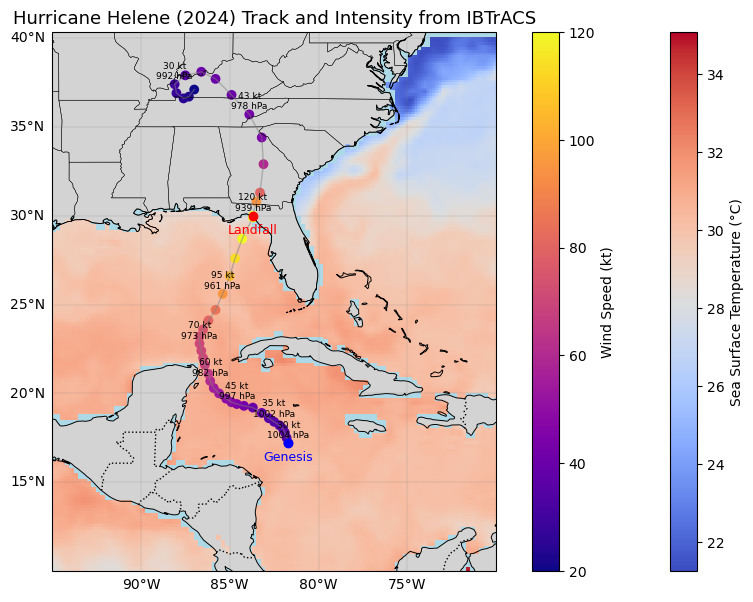

In [10]:
#begin plotting by specifying the figure size, selecting the PlateCarree projection style, and setting the axis extent to the area that best captures Helene's track
fig = plt.figure(figsize=(10,7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-95, -70, 10, 40])  # adjust for Atlantic view

#map features - aesthetics 
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linewidth=0.3)


#SSTs add first, make sure to plot Hurricane Helene's track info on top of the shading. Use the smoothly plotted sst_interip defined above. Remove dimensions of size 1 that are placeholders 
sst_plot = ax.pcolormesh(sst_interp.longitude, sst_interp.latitude, sst_interp.squeeze(), cmap='coolwarm', shading='auto', transform=ccrs.PlateCarree(), alpha=1)
plt.colorbar(sst_plot, ax=ax, fraction=0.04, pad=0.04, label='Sea Surface Temperature (°C)')


#scatter Helene's corresponding wind data organized by coordinates with the plasma colorbar option
sc = ax.scatter(helene['LON'], helene['LAT'], c=helene['USA_WIND'], cmap='plasma', s=50, edgecolors='none', linewidth=0.5, transform=ccrs.PlateCarree())
plt.colorbar(sc, ax=ax, label='Wind Speed (kt)')

#to reduce the density of labeled points, label only every 5 points of Helene's track with wind and pressure data using the iloc method in a loop (ChatGPT helped me with this loop)
for i, row in helene.iloc[::5].iterrows():
    label = f"{int(row['USA_WIND'])} kt\n{int(row['USA_PRES'])} hPa"
    ax.text(row['LON'], row['LAT'] + 0.3, label, fontsize=6.5, color='black', ha='center', transform=ccrs.PlateCarree())

#plot Helene's lat and lon points 
ax.plot(helene['LON'], helene['LAT'], color='gray', linewidth=1, transform=ccrs.PlateCarree(), alpha=0.5)

#label the genesis point 
ax.text(helene['LON'].iloc[0], helene['LAT'].iloc[0]-1, 'Genesis', fontsize=9, ha='center', color='blue', transform=ccrs.PlateCarree())
ax.plot(helene['LON'].iloc[0], helene['LAT'].iloc[0], 'bo', transform=ccrs.PlateCarree())

#label Helene's landfall point
ax.text(helene['LON'].iloc[-15], helene['LAT'].iloc[-15] - 1, 'Landfall', fontsize=9, ha='center', color='red', transform=ccrs.PlateCarree())
ax.plot(helene['LON'].iloc[-15], helene['LAT'].iloc[-15], 'ro', transform=ccrs.PlateCarree())

#add gridlines and a title 
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
plt.title("Hurricane Helene (2024) IBTrACS Track, Intensity, and Sea Surface Temperatures", fontsize=13)

### The high SSTs at and above 30C make sense given that Helene formed out of the Central American Gyre region. Ideal SST temperatures broadly around 30-32 degrees Celsius provide sufficient latent energy for the genesis and intensification of a tropical cyclone, and some literature even proposes that uniformly high SSTs can reduce baroclinicity and thus windshear over a region.

### Windshear also plays a factor in TC formation, with little to no shear seen as an ideal scenario for quick intensification and organization of a warm core low pressure system that benefits from a vertical and symmetric structure and a barotropic (not baroclinic environment). Let's plot the 200hPa winds which one can assume would be geostropically balanced in the upper atmosphere. Stronger winds in particular areas of the map would indicate the presence of the jetstream or baroclinicity, which is not conducive to TC development. If Helene's center is noticibly clear of the jetstream, then the environment it develops in would be barotropic and ideal.

### Let's plot Helene over three times, once during genesis and twice as it nears landfall and moves further north where the odds of jetstream interactions increase.

## Second Section: Steering Flow and Baroclinicity/Jetstream Location

In [11]:
c = cdsapi.Client()
c.retrieve(
    'reanalysis-era5-pressure-levels',
    {
        'product_type': 'reanalysis',
        'variable': ['u_component_of_wind', 'v_component_of_wind'],
        'pressure_level': ['850','700','500','300','200'],
        'year': '2024',
        'month': '09',
        'day': ['19', '26', '27'],
        'time': '00:00',  # three times
        'area': [40, -95, 10, -70],
        'format': 'netcdf',
    },
    'era5_winds_steering_helene_3days.nc'
)

2025-11-25 05:43:33,867 INFO Request ID is 8c465abd-b480-43fe-a654-1d02de03c916
2025-11-25 05:43:33,978 INFO status has been updated to accepted
2025-11-25 05:43:39,595 INFO status has been updated to running
2025-11-25 05:43:48,485 INFO status has been updated to successful


ccc9cdc54eec164b766d9bd21a3277ba.nc:   0%|          | 0.00/820k [00:00<?, ?B/s]

'era5_winds_steering_helene_3days.nc'

/tmp/ipykernel_1218183/2160408792.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.12, 1, 0.95], w_pad=0.1)


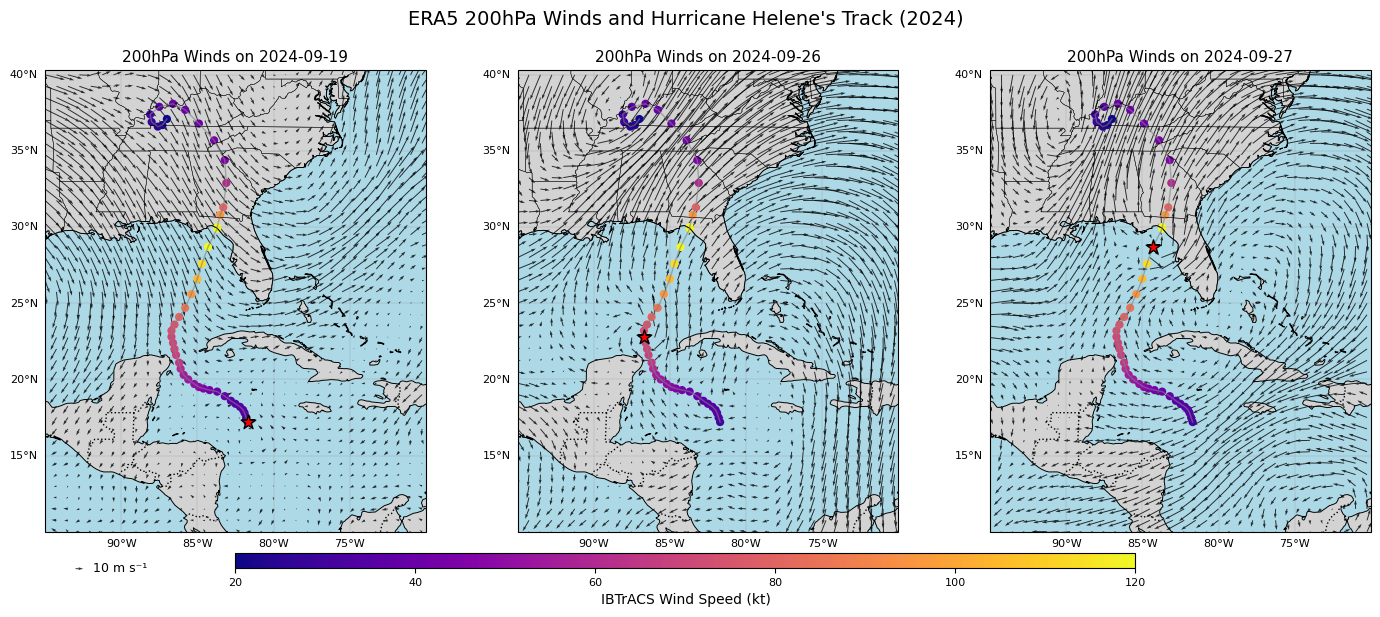

In [12]:
#open dataset generated above and make sure valid time is selected
ds = xr.open_dataset('era5_winds_steering_helene_3days.nc')
times = ds['valid_time'].values

#3 figure subplot panel 
fig, axs = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': ccrs.PlateCarree()}, gridspec_kw={'wspace': 0.05})

#use enumerate to loop over and alter axis and time for all 3 subplots
for i, (ax, t) in enumerate(zip(axs, times)):
    #features and extent lat lon set
    ax.set_extent([-95, -70, 10, 40])
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.STATES, linewidth=0.3)

    #200hPa wind components
    u = ds['u'].sel(pressure_level=200, valid_time=t)
    v = ds['v'].sel(pressure_level=200, valid_time=t)

    #make the lat and lons latitude and longitude, ensure - ChatGPT troubleshooting 
    if 'lat' in u.dims: u = u.rename({'lat': 'latitude'})
    if 'lon' in u.dims: u = u.rename({'lon': 'longitude'})
    if 'lat' in v.dims: v = v.rename({'lat': 'latitude'})
    if 'lon' in v.dims: v = v.rename({'lon': 'longitude'})

    #Cartopy sanity check - does the latitude increase from bottom to top, and does the latitude increase from left to right - ChatGPT troubleshooting 
    u = u.sortby('longitude'); v = v.sortby('longitude')
    if u.latitude[0] > u.latitude[-1]:
        u = u.sortby('latitude'); v = v.sortby('latitude')

    #reduce windbarb density by plotting only 1/3 of points using .isel() method; do this before quiver so the density is reduced in advance
    skip = 3
    u_plt = u.isel(latitude=slice(0, None, skip), longitude=slice(0, None, skip))
    v_plt = v.isel(latitude=slice(0, None, skip), longitude=slice(0, None, skip))
    lon, lat = np.meshgrid(u_plt.longitude, u_plt.latitude)

    #windbarb creation
    q = ax.quiver(lon, lat, u_plt, v_plt, scale=500, width=0.0025, transform=ccrs.PlateCarree(), color='black', alpha=0.8)


    #IBTrACS plotting for full track
    ax.plot(helene['LON'], helene['LAT'], color='gray', linewidth=1, transform=ccrs.PlateCarree(), alpha=0.6)
    sc = ax.scatter(helene['LON'], helene['LAT'], c=helene['USA_WIND'], cmap='plasma', s=35, transform=ccrs.PlateCarree(), edgecolors='none')

    #finding the nearest IBTrACS time to current ERA5 valid_time to mark Helene's center - ChatGPT helped 
    idx = np.argmin(np.abs(helene['ISO_TIME'] - np.datetime64(t, 'h'))) #find nearest corresponding IBTrACS and note lat and lon, then mark with red star
    lon_c = helene['LON'].iloc[idx]
    lat_c = helene['LAT'].iloc[idx]
    ax.scatter(lon_c, lat_c, color='red', marker='*', s=120, edgecolors='black', transform=ccrs.PlateCarree(), zorder=5, label='Helene center')

    #reference windbarb only displayed on first subplot to avoid repetition, ChatGPT helped me get this for only the first plot 
    if i == 0:
        ax.quiverkey(q, X=0.1, Y=-0.08, U=10, label='10 m s⁻¹', labelpos='E', coordinates='axes', fontproperties={'size': 9})


    #title and formatting 
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}

    date_str = np.datetime_as_string(t, unit='D')
    ax.set_title(f"200hPa Winds on {date_str}", fontsize=11)

#title for all 
plt.suptitle("ERA5 200hPa Upper Level Winds and Hurricane Helene's Track (2024)", fontsize=14)
plt.tight_layout(rect=[0, 0.12, 1, 0.95], w_pad=0.1)

#colorbar for windspeed
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])  
cb = fig.colorbar(sc, cax=cbar_ax, orientation='horizontal')
cb.set_label('IBTrACS Wind Speed (kt)', fontsize=10)
cb.ax.tick_params(labelsize=8)

plt.show()

### With Helene's center marked in red, notice how any apparent troughing over the Southeast US didn't overlap with the system, particularly in its genesis phase on September 19th. While there could be some wind shear, especially nearing landfall, it wasn't enough to tear the storm apart or misalign the upperlevel warm core from the low pressure center. Helene was a category 4 at its peak with 140MPH winds, and any further intensification was held off by an eyewall replacement cycle.

### A notable feature about Helene was the high confidence in its track/cone of uncertainty that was well forecasated over a week away from its landfall. The high confidence in its track is explained by the steering flow, or the averaged winds between 850-200hPa, that help advect or "steer" the system. With the Bermuda High to the east and troughing to the west, the anticyclonic and cyclonic flows worked together to create a "channel" of winds flowing in the same direction right towards the Panhandle of Florida. There virtually was nowhere for Helene to go. To visualize this idea, three times are plotted below for the steering flow as Helene approaches the Florida Coast.

/tmp/ipykernel_1218183/1659722869.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.12, 1, 0.95], w_pad=0.1)


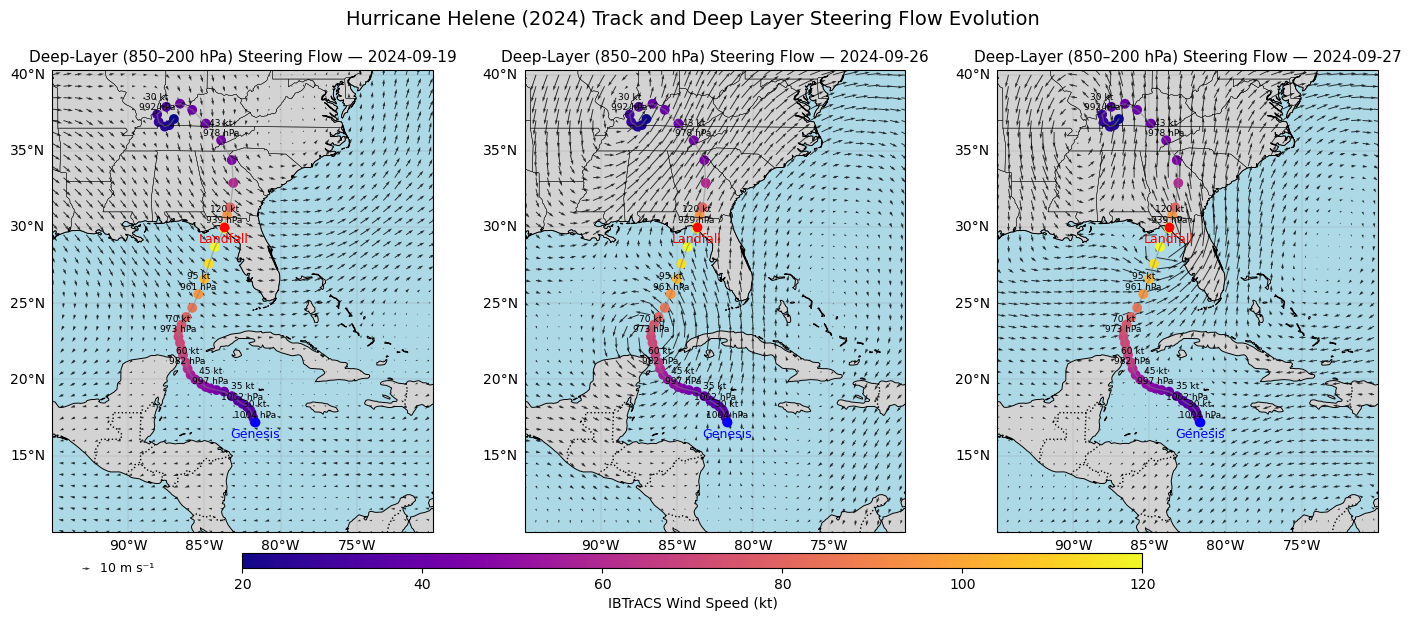

In [13]:
#open dataset generated above and make sure valid time is selected
ds = xr.open_dataset('era5_winds_steering_helene_3days.nc')
times = ds['valid_time'].values

#3 figure subplot panel 
fig, axs = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': ccrs.PlateCarree()}, gridspec_kw={'wspace': 0.05}  )

#use enumerate to loop over and alter axis and time for all 3 subplots
for i, (ax, t) in enumerate(zip(axs, times)):
    #features and extent lat lon set
    ax.set_extent([-95, -70, 10, 40])
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.STATES, linewidth=0.3)

    #850–200hPa steering flow load in data with the slice method
    u = ds['u'].sel(valid_time=t, pressure_level=slice(850, 200)).mean(dim='pressure_level')
    v = ds['v'].sel(valid_time=t, pressure_level=slice(850, 200)).mean(dim='pressure_level')

    #    #make the lat and lons latitude and longitude, ensure - ChatGPT troubleshooting 
    if 'lat' in u.dims:   u = u.rename({'lat': 'latitude'})
    if 'lon' in u.dims:   u = u.rename({'lon': 'longitude'})
    if 'lat' in v.dims:   v = v.rename({'lat': 'latitude'})
    if 'lon' in v.dims:   v = v.rename({'lon': 'longitude'})

    #Cartopy sanity check - does the latitude increase from bottom to top, and does the latitude increase from left to right - ChatGPT troubleshooting 
    u = u.sortby('longitude'); v = v.sortby('longitude')
    if u.latitude[0] > u.latitude[-1]:
        u = u.sortby('latitude'); v = v.sortby('latitude')

    #reduce windbarb density by plotting only 1/3 of points using .isel() method; do this before quiver so the density is reduced in advance
    skip = 3
    u_plt = u.isel(latitude=slice(0, None, skip), longitude=slice(0, None, skip))
    v_plt = v.isel(latitude=slice(0, None, skip), longitude=slice(0, None, skip))
    lon, lat = np.meshgrid(u_plt.longitude, u_plt.latitude)

    #windbarb creation
    q = ax.quiver(lon, lat, u_plt, v_plt, scale=500, width=0.0025, transform=ccrs.PlateCarree(), color='k', alpha=0.8)

    #reference windbarb only displayed on first subplot to avoid repetition, ChatGPT helped me get this for only the first plot 
    if i == 0:
        ax.quiverkey(q, X=0.1, Y=-0.08, U=10, label='10 m s⁻¹', labelpos='E', coordinates='axes', fontproperties={'size': 9})

    #IBTrACS plotting for full track
    ax.plot(helene['LON'], helene['LAT'], color='gray', linewidth=1, transform=ccrs.PlateCarree(), alpha=0.5)
    sc = ax.scatter(helene['LON'], helene['LAT'], c=helene['USA_WIND'], cmap='plasma', s=50, edgecolors='none', transform=ccrs.PlateCarree())

    # Label a few track points
    for j, row in helene.iloc[::5].iterrows():
        label = f"{int(row['USA_WIND'])} kt\n{int(row['USA_PRES'])} hPa"
        ax.text(row['LON'], row['LAT'] + 0.3, label, fontsize=6.5, color='black', ha='center', transform=ccrs.PlateCarree())

    #genesis and landfall points marked using the .iloc() method on the first index and index corresponding to landfall
    ax.text(helene['LON'].iloc[0], helene['LAT'].iloc[0]-1, 'Genesis', fontsize=9, ha='center', color='blue', transform=ccrs.PlateCarree())
    ax.plot(helene['LON'].iloc[0], helene['LAT'].iloc[0], 'bo', transform=ccrs.PlateCarree())

    ax.text(helene['LON'].iloc[-15], helene['LAT'].iloc[-15]-1, 'Landfall', fontsize=9, ha='center', color='red', transform=ccrs.PlateCarree())
    ax.plot(helene['LON'].iloc[-15], helene['LAT'].iloc[-15], 'ro', transform=ccrs.PlateCarree())

    #gridlines for aesthetics 
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    date_str = np.datetime_as_string(t, unit='D')
    ax.set_title(f"Deep Layer (850–200 hPa) Steering Flow — {date_str}", fontsize=11)

#title for all 
plt.suptitle("Hurricane Helene (2024) Track and Deep Layer Steering Flow Evolution", fontsize=14)
plt.tight_layout(rect=[0, 0.12, 1, 0.95], w_pad=0.1)

#colorbar for windspeed
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cb = fig.colorbar(sc, cax=cbar_ax, orientation='horizontal')
cb.set_label('IBTrACS Wind Speed (kt)')

plt.show()

### The channel of winds mentioned above is quite apparent in panel 2, on September 26th. 

### To visualize the structure and strengthening of Helene, visible and infrared satellite can be used to observe the concentricity and symmetry of the system. The more symmetrical a hurricane and its variables are (pressure, winds), the more of an effective heat engine it can be, and it is able to theoretically reach its maximum potential intensity (MPI) under idealized conditions. 

## Third Section: GOES-16 IR and Visible Satellite Imagery

### I had ChatGPT help me load in this s3fs data for GOES16 as I am still somewhat unfamiliar working with it

In [18]:
#AWS data now using s3fs package
fs = s3fs.S3FileSystem(anon=True)

#ChatGPT helped me load in this dataset 
def open_goes16_from_aws(year, month, day, hour, channel):
    """Open a GOES-16 ABI-L2-CMIPF file directly from AWS without downloading."""
    doy = dt.date(year, month, day).timetuple().tm_yday
    prefix = f'noaa-goes16/ABI-L2-CMIPF/{year}/{doy:03d}/{hour:02d}/'
    files = fs.ls(prefix)
    match = [f for f in files if f'M6C{channel:02d}' in f]
    if not match:
        print(f"No file for {year}-{month}-{day} hour {hour} Channel {channel}")
        return None
    remote_path = 's3://' + match[0]
    print("Opening:", remote_path)
    # open remotely
    ds = xr.open_dataset(fs.open(remote_path, mode='rb'))
    return ds

#open data for 3 days of my choosing 
dates = [(2024,9,19), (2024,9,26), (2024,9,27)]
datasets = [open_goes16_from_aws(y,m,d,12,13) for (y,m,d) in dates]

Opening: s3://noaa-goes16/ABI-L2-CMIPF/2024/263/12/OR_ABI-L2-CMIPF-M6C13_G16_s20242631200205_e20242631209525_c20242631209593.nc
Opening: s3://noaa-goes16/ABI-L2-CMIPF/2024/270/12/OR_ABI-L2-CMIPF-M6C13_G16_s20242701200209_e20242701209528_c20242701209598.nc
Opening: s3://noaa-goes16/ABI-L2-CMIPF/2024/271/12/OR_ABI-L2-CMIPF-M6C13_G16_s20242711200209_e20242711209529_c20242711210011.nc


### I was able to plot a standalone image projection, but I also asked ChatGPT to loop my code for 3 panels to provide 3 snapshots of Helene's formation and intensification as opposed to one. I also needed help setting up the satellite plotting initially, as it wasn;t intuitive to me to factor in the satellite's distance from Earth etc. and my plotting previously looked off. 

In [19]:
# Loop through each subplot axis (ax) and corresponding dataset (ds)
for ax, ds in zip(axs, datasets):  
    #if the dataset is missing, go to the next dataset and skip that iteration of the loop with continue
    if ds is None:
        continue

    #get GOES satellite metadata 
    g = ds['goes_imager_projection']
    sat_h = g.perspective_point_height  #this is the height above Earth's surface for the satellite

    #convert angle coordinates to true distances by multiplying by satellite height
    x = ds['x'] * sat_h
    y = ds['y'] * sat_h

    #brightness temperature Kelvin to Celsius
    bt = ds['CMI'] - 273.15  

    #use pcolormesh to plot temp field on geostationary projection
    im = ax.pcolormesh(
        x, y, bt, cmap='inferno_r', shading='auto',
        transform=ccrs.Geostationary(
            satellite_height=sat_h,
            central_longitude=g.longitude_of_projection_origin,
            sweep_axis=g.sweep_angle_axis
        )
    )

    #map features 
    ax.set_extent([-95, -70, 10, 40], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.STATES, linewidth=0.3)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=-1)

    #dynamic title to figure displaying the day
    time_str = np.datetime_as_string(ds['t'].values, unit='m')
    ax.set_title(f"GOES-16 ABI Ch 13 Infrared Radiation {time_str}", fontsize=11)

### Time to plot the IR imagery for the 22nd, 24th, and 26th of September as Helene approaches the Florida Panhandle. Brightness temeratures that are lower or "cooler" indicate deeper convection from taller cloudtops that reach cooler parts of the troposphere. Colder cloudtops are a noticable and common parameter to investigate when looking for intensification in a TC

:::{warning}
This takes some time to load...
:::

📂 Opening: s3://noaa-goes16/ABI-L2-CMIPF/2024/263/00/OR_ABI-L2-CMIPF-M6C13_G16_s20242630000203_e20242630009523_c20242630009572.nc
📂 Opening: s3://noaa-goes16/ABI-L2-CMIPF/2024/270/00/OR_ABI-L2-CMIPF-M6C13_G16_s20242700000207_e20242700009526_c20242700009585.nc
📂 Opening: s3://noaa-goes16/ABI-L2-CMIPF/2024/271/00/OR_ABI-L2-CMIPF-M6C13_G16_s20242710000207_e20242710009527_c20242710009591.nc


/tmp/ipykernel_1218183/2232931201.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.12, 1, 0.95], w_pad=0.1)


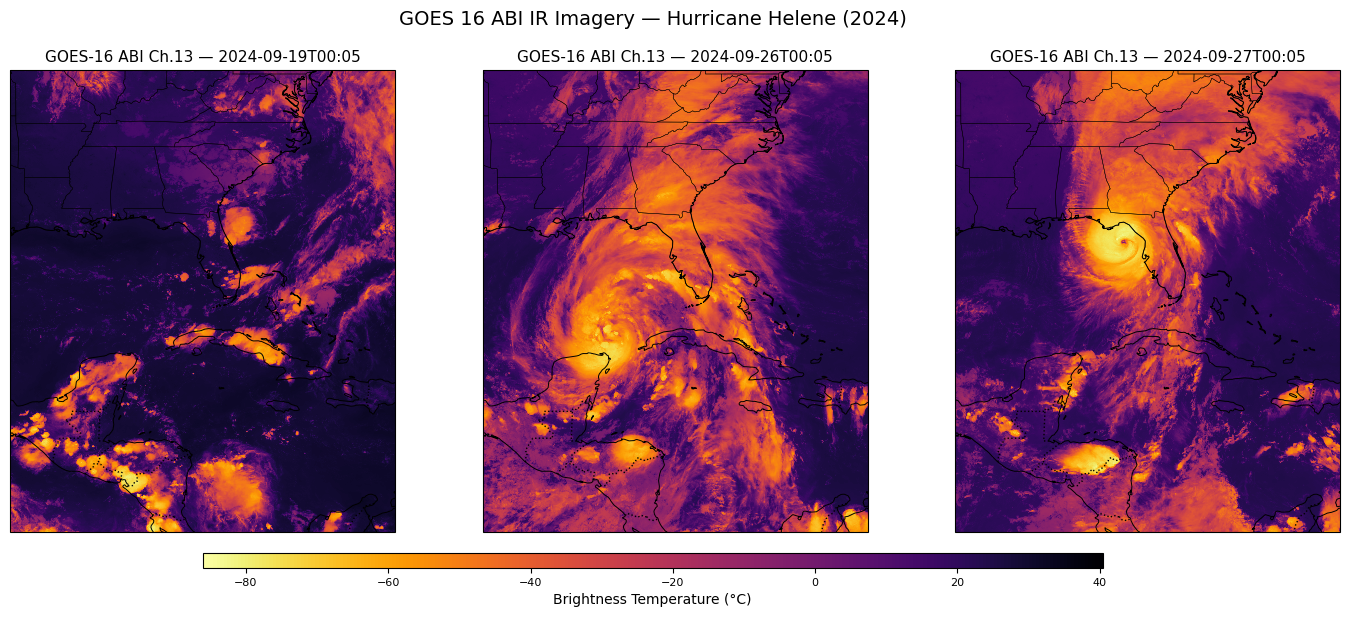

In [21]:
plot_type = "IR"   #can change it from IR to VIS
dates = [(2024, 9, 19), (2024, 9, 26), (2024, 9, 27)] 
hour = 00          #select dates and hour, could have a list of hour too
satellite = "noaa-goes16"

#makes it easy to switch between IR and VIS which are the two bands of greatest interest 
if plot_type == "IR":
    channel = 13
    cmap = "inferno_r"
    label = "Brightness Temperature (°C)"
else:
    channel = 2
    cmap = "Greys_r"
    label = "Reflectance (%)"

#time to load in data with the s3fs package, ChatGPT helped with this part
fs = s3fs.S3FileSystem(anon=True)

def open_goes16_from_aws(year, month, day, hour, channel):
    """Open GOES-16 ABI file from AWS"""
    doy = dt.date(year, month, day).timetuple().tm_yday
    prefix = f"{satellite}/ABI-L2-CMIPF/{year}/{doy:03d}/{hour:02d}/"
    try:
        files = fs.ls(prefix)
    except FileNotFoundError:
        print(f"FileNotFound")
        return None

    match = [f for f in files if f"M6C{channel:02d}" in f]
    if not match:
        print(f"No file for {year}-{month}-{day} hour {hour} Ch{channel:02d}")
        return None

    remote_path = "s3://" + match[0]
    print("📂 Opening:", remote_path)
    ds = xr.open_dataset(fs.open(remote_path, mode="rb"))
    return ds


datasets = [open_goes16_from_aws(y, m, d, hour, channel) for (y, m, d) in dates]

#plotting
fig, axs = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': ccrs.PlateCarree()}, gridspec_kw={'wspace': 0.05})

for ax, ds in zip(axs, datasets): #loop over 3 times and change the axes and dataset with zip
    if ds is None: #skip over missing datasets 
        continue

    g = ds['goes_imager_projection']
    sat_h = g.perspective_point_height
    proj = ccrs.Geostationary(
        satellite_height=sat_h,
        central_longitude=g.longitude_of_projection_origin,
        sweep_axis=g.sweep_angle_axis
    )

    #coordinates conversion factoring in satellite height 
    x = ds['x'] * sat_h
    y = ds['y'] * sat_h
    if plot_type == "IR":
        data = ds['CMI'] - 273.15 #Kelvin to Celsius 
    else:
        data = ds['CMI'] * 100 #or reflectance % if VIS is selected 

    #plot
    im = ax.pcolormesh(x, y, data, cmap=cmap, shading="auto", transform=proj)

    #features
    ax.set_extent([-95, -70, 10, 40], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.STATES, linewidth=0.3)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=-1)

    #get times for title 
    t_val = ds['t'].values
    if np.ndim(t_val) > 0:
        t_val = t_val.item()
    time_str = np.datetime_as_string(t_val, unit='m')
    ax.set_title(f"GOES-16 ABI Ch.{channel:02d} — {time_str}", fontsize=11)

#formatting, main title 
plt.suptitle(f"GOES 16 ABI {plot_type} Imagery — Hurricane Helene (2024)", fontsize=14)
plt.tight_layout(rect=[0, 0.12, 1, 0.95], w_pad=0.1)

#colorbar plot 
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cb = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cb.set_label(label, fontsize=10)
cb.ax.tick_params(labelsize=8)

plt.show()

### Let's plot the visible spectrum through reflectance on channel 2 of GOES 16 now, and change the hour to 15 during the midmorning for ease of viewing the system completely. The days stay the same. Visible satellite helps look at the overall storm structure and concentricity, and can help visualize how mature the system and its center is. 

:::{warning}
This visible reflectance code could take a significantly longer time than the IR channel to visualize... Upwards of 30 minutes but I used ChatGPT's help to reduce its plotting time through .imshow() and h5netcdf
:::

📂 Opening: s3://noaa-goes16/ABI-L2-CMIPF/2024/263/15/OR_ABI-L2-CMIPF-M6C02_G16_s20242631500206_e20242631509514_c20242631509584.nc
📂 Opening: s3://noaa-goes16/ABI-L2-CMIPF/2024/269/15/OR_ABI-L2-CMIPF-M6C02_G16_s20242691500209_e20242691509517_c20242691509575.nc
📂 Opening: s3://noaa-goes16/ABI-L2-CMIPF/2024/270/15/OR_ABI-L2-CMIPF-M6C02_G16_s20242701500209_e20242701509517_c20242701509584.nc


/tmp/ipykernel_1218183/317486278.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.12, 1, 0.95], w_pad=0.1)


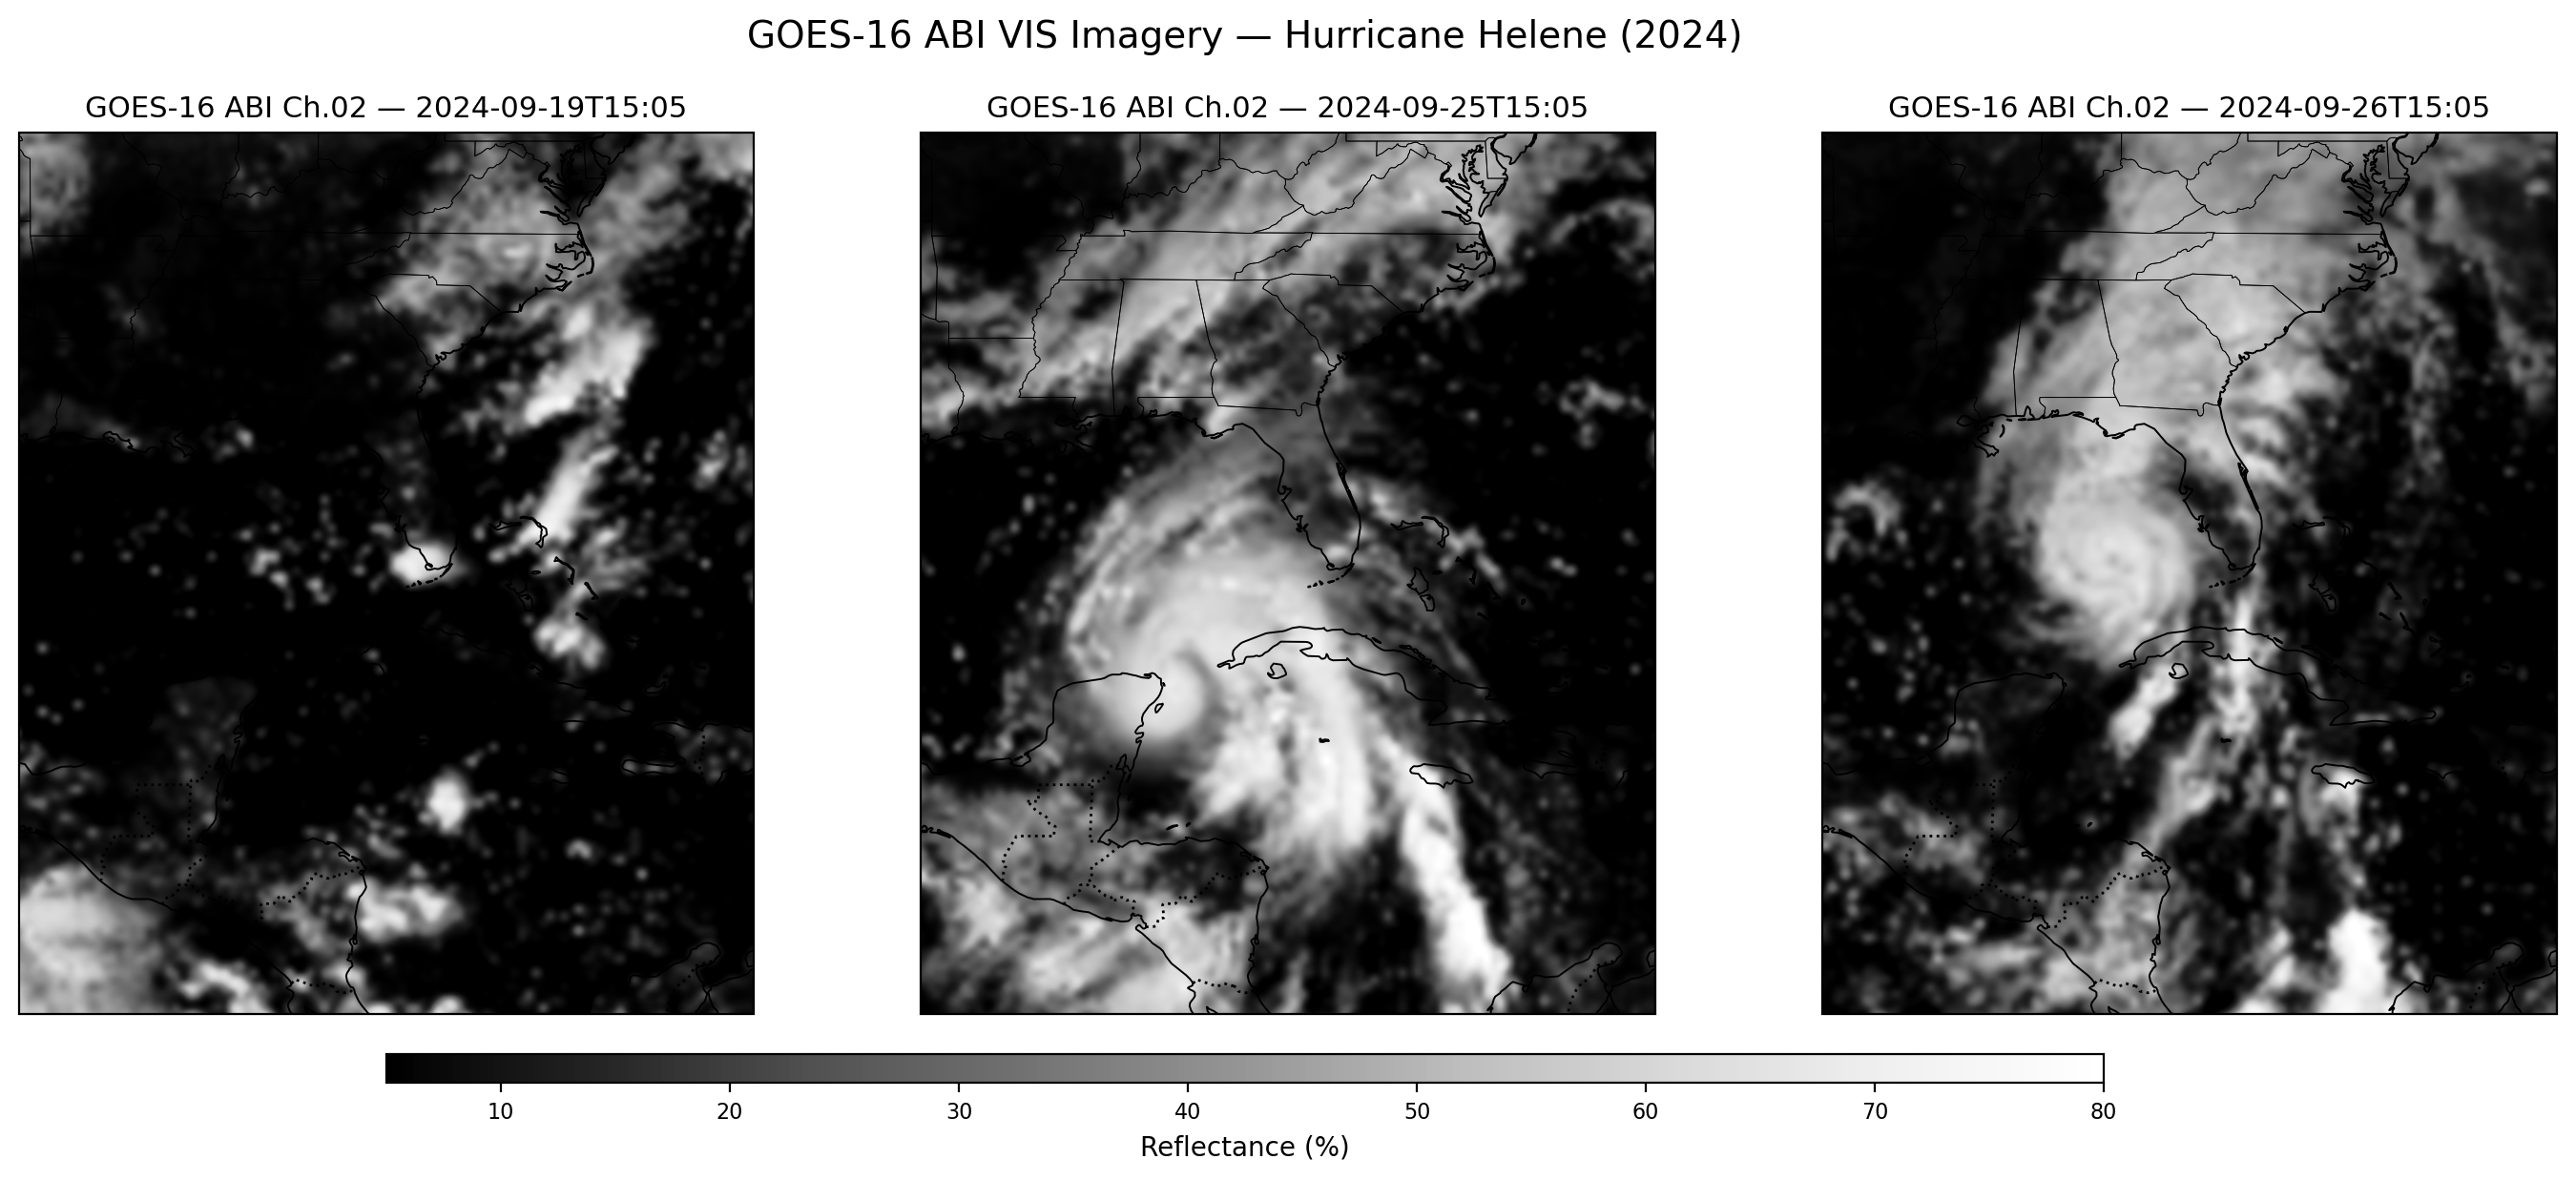

In [26]:
import datetime as dt
import s3fs
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from concurrent.futures import ThreadPoolExecutor

plot_type = "VIS"   # "IR" or "VIS"
dates = [(2024, 9, 19), (2024, 9, 25), (2024, 9, 26)]
hour = 15
satellite = "noaa-goes16"

# ---- VIS vs IR settings ----
if plot_type == "IR":
    channel = 13
    cmap = "inferno_r"
    label = "Brightness Temperature (°C)"
    coarsen_factor = 1      # no coarsen needed
else:
    channel = 2
    cmap = "Greys_r"
    label = "Reflectance (%)"
    coarsen_factor = 4      # 4x coarsen → big speedup

# s3 filesystem
fs = s3fs.S3FileSystem(anon=True)

# ---- open GOES16 from AWS, no spatial subset (bulletproof) ----
def open_goes16_from_aws(year, month, day, hour, channel):
    doy = dt.date(year, month, day).timetuple().tm_yday
    prefix = f"{satellite}/ABI-L2-CMIPF/{year}/{doy:03d}/{hour:02d}/"

    try:
        files = fs.ls(prefix)
    except FileNotFoundError:
        print("No files found", prefix)
        return None

    match = [f for f in files if f"M6C{channel:02d}" in f]
    if not match:
        print("No match for", year, month, day, hour)
        return None

    remote_path = "s3://" + match[0]
    print("📂 Opening:", remote_path)

    # h5netcdf + chunking → much faster than default
    ds = xr.open_dataset(
        fs.open(remote_path, mode="rb"),
        engine="h5netcdf",
        chunks="auto"
    )

    return ds


# ---- parallel load datasets ----
with ThreadPoolExecutor(max_workers=3) as ex:
    datasets = list(ex.map(
        lambda t: open_goes16_from_aws(*t, hour, channel),
        dates
    ))

# ---- plotting ----
fig, axs = plt.subplots(
    1, 3, figsize=(18, 6), dpi=200, 
    subplot_kw={'projection': ccrs.PlateCarree()},
    gridspec_kw={'wspace': 0.05}
)

for ax, ds in zip(axs, datasets):
    if ds is None:
        continue

    g = ds['goes_imager_projection']
    sat_h = g.perspective_point_height

    proj = ccrs.Geostationary(
        satellite_height=sat_h,
        central_longitude=g.longitude_of_projection_origin,
        sweep_axis=g.sweep_angle_axis,
    )

    x = (ds['x'] * sat_h).values
    y = (ds['y'] * sat_h).values

    data = ds['CMI']

    if plot_type == "IR":
        data = data - 273.15   # K → °C
    else:
        data = data * 100      # reflectance (%)

        # ---- SAFE coarsen: only if dims are big enough ----
        if 'x' in data.dims and 'y' in data.dims:
            nx = data.sizes['x']
            ny = data.sizes['y']
            if nx >= coarsen_factor and ny >= coarsen_factor:
                data = data.coarsen(
                    x=coarsen_factor,
                    y=coarsen_factor,
                    boundary="trim"
                ).mean()
            else:
                print("⚠️ Data too small to coarsen, skipping.")
        else:
            print("⚠️ 'x'/'y' not in dims, skipping coarsen.")

    #imshow is much faster than pcolormesh for big grids
    im = ax.imshow(
        data,
        extent=[x.min(), x.max(), y.min(), y.max()],
        origin="upper",
        cmap=cmap,
        transform=proj,
        interpolation="bicubic",
        vmin=5,      #brighten low end
        vmax=80      #cap clouds so they don’t blow out
    )


    # map features + extent (lat/lon)
    ax.set_extent([-95, -70, 10, 40], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.STATES, linewidth=0.3)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=-1)

    # title from time variable
    t_val = ds['t'].values
    if np.ndim(t_val) > 0:
        t_val = t_val.item()
    time_str = np.datetime_as_string(t_val, unit='m')
    ax.set_title(f"GOES-16 ABI Ch.{channel:02d} — {time_str}", fontsize=11)

plt.suptitle(f"GOES-16 ABI {plot_type} Imagery — Hurricane Helene (2024)", fontsize=14)
plt.tight_layout(rect=[0, 0.12, 1, 0.95], w_pad=0.1)

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cb = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cb.set_label(label, fontsize=10)
cb.ax.tick_params(labelsize=8)

plt.show()


### Is there a trick to visualize this better by manipulating RGB? 

---

:::{note}
I am wanting to structure this notebook better and I was upset to see that the NHC wind radii dataset was a placeholder on their website. I was also curious about loading in some realtime lightning data, but I don't know if that is appropriate for the scope of this project. The dataset seems difficult to obtain. I would also like to visualize the visible imagery better for Helene.
:::

## Summary 
The storm surge impacts of Helene on Florida highlight the compound nature of coastal hazard risk. Although Helene may not have had the highest wind speeds, its broad wind field and relatively slow land-interaction phase allowed for sustained onshore pressure gradients that elevated surge levels along vulnerable stretches of coastline. Coupled with elevated bathymetry and the presence of shallow continental shelf zones along parts of Florida’s coast, the surge effects were amplified. The observational water-level time-series from the NOAA Center for Operational Oceanographic Products and Services (CO-OPS) dataset reveal residual surge values that exceeded model forecasts, reinforcing that local bathymetric and meteorological factors can meaningfully modulate surge during storms of moderate intensity.

---

### What's Next?

Potential next steps include:

- Compare Helene’s evolution to other 2024 Atlantic storms
- Investigate the eyewall replacement cycle and lightning intensity
- Look at the wind radii/swath and compare it to other hurricanes that come from the Central American Gyre
- Analyze whether a LL Easterly Jet is involved in Helene's genesis (or other factors that enhance LL convergence)  

---

## Resources and References

**Datasets**
- [ERA5 Reanalysis (C3S, 2023)](https://cds.climate.copernicus.eu/cdsapp#!/dataset/reanalysis-era5) — atmospheric variables at pressure and single levels  
- [IBTrACS v4 (NOAA NCEI, 2024)](https://www.ncei.noaa.gov/products/international-best-track-archive) — best-track tropical cyclone data  

**Software & Tools**
- [xarray](https://docs.xarray.dev) and [pandas](https://pandas.pydata.org/) for data manipulation  
- [Cartopy](https://scitools.org.uk/cartopy/docs/latest/) and [Matplotlib](https://matplotlib.org/) for mapping and visualization  
- [Project Pythia Foundations](https://foundations.projectpythia.org) for reproducible workflow guidance  

**Further Reading**
- Doswell, C. A., Brooks, H. E., & Maddox, R. A. (1996). *Flash flood forecasting: An ingredients-based methodology.* *Weather and Forecasting, 11*(3), 560–581.  
- Kaplan, J., & DeMaria, M. (2003). *Large-scale characteristics of rapidly intensifying tropical cyclones in the North Atlantic basin.* *Weather and Forecasting, 18*, 1093–1108.  